<h1><center> Land Marks Detection Using Mars orbital images (HiRISE) By NASA  </center></h1>

<h4>☕ Realisé par:</h4>
<ul>
    <li>Rajaa Lebnaiti</li>
</ul>


<h5> ✉ Email:   <a href="mailto:rajaa.lebnaiti@gmail.com">  rajaa.lebnaiti@gmail.com</a></h5>
<h5>🌐 LinkedIn:   <a href="https://www.linkedin.com/in/lebnaiti-rajaa/" target="_blank">  https://www.linkedin.com/in/lebnaiti-rajaa/</a></h5>
<h5>💼 GitHub:   <a href="https://github.com/RajaaLebnaiti" target="_blank">  https://github.com/RajaaLebnaiti/</a></h5>




In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
from PIL import Image
import shutil

from collections import Counter


from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


E0000 00:00:1739708442.479121      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


<h1>1. Upload the Data</h1>

In [2]:
# a. upload the dataset 
data_path = '/kaggle/input/datasetsnasa/Projet data science NASA/dataset' 

In [3]:
# b. upload and read labels_map_proj_v3.txt 
labels_map_proj_v3 = '/kaggle/input/datasetsnasa/Projet data science NASA/labels-map-proj-v3.txt'

In [4]:
# Show the first 5 rows of the file
with open(labels_map_proj_v3, 'r') as f:
    print(f"Contenu de labels_map_proj_v3.txt:\n{''.join(f.readlines()[:5])}")

Contenu de labels_map_proj_v3.txt:
ESP_011623_2100_RED-0069.jpg 0
ESP_011623_2100_RED-0069-r90.jpg 0
ESP_011623_2100_RED-0069-r180.jpg 0
ESP_011623_2100_RED-0069-r270.jpg 0
ESP_011623_2100_RED-0069-fh.jpg 0



In [5]:
# c. upload and read landmarks_map-proj-v3_classmap.csv
landmarks_map_proj_v3_classmap = '/kaggle/input/datasetsnasa/Projet data science NASA/landmarks_map-proj-v3_classmap.csv'

In [6]:
classmap_df = pd.read_csv(landmarks_map_proj_v3_classmap)
print(classmap_df.head(8))

   0          other
0  1         crater
1  2      dark dune
2  3   slope streak
3  4    bright dune
4  5  impact ejecta
5  6   swiss cheese
6  7         spider


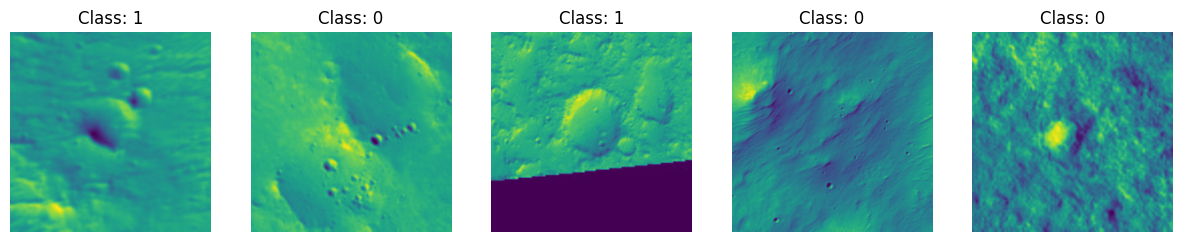

In [7]:
#c. plot some images with their label

# Load the labels in a dictionnary
image_labels = {}    # declare an empty dictionnary we can also use dic() instead of {}


with open(labels_map_proj_v3, 'r') as f:    # open the file in reading mode 'r'
    for line in f:  # for each line of the file
        parts = line.strip().split()  # we do a strip to delete spaces at the begining and at the end, then after that we do a split based on the space " " the space between image.jpg and the corresponding class
        if len(parts) == 2:  # if the split caused 2 different parts then we stock this 2 parts in our dictionanry
            image_labels[parts[0]] = int(parts[1])  # Ex: {'ESP_011623_2100_RED-0069.jpg': 0}




# Liste of all images in the directory path
image_files = os.listdir(data_path)




# Select 5 random images
random_images = random.sample(image_files, 5)

# Show images with their labels
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for ax, img_name in zip(axes, random_images):
    img_path = os.path.join(data_path, img_name)
    img = Image.open(img_path)
    
    # Find the class of the image
    label = image_labels.get(img_name, "Unknown")  # we use get() that takes as input the name of image.jpg and return her corrsponding class from the dictionnary if not found we return 'unkown'

    ax.imshow(img)
    ax.set_title(f"Class: {label}")
    ax.axis("off")

plt.show()


<h1>2. Data Exploration</h1>

Number of images per classe :
Classe 0: 61054 images
Classe 5: 231 images
Classe 1: 4900 images
Classe 3: 2331 images
Classe 2: 1141 images
Classe 6: 1148 images
Classe 7: 476 images
Classe 4: 1750 images


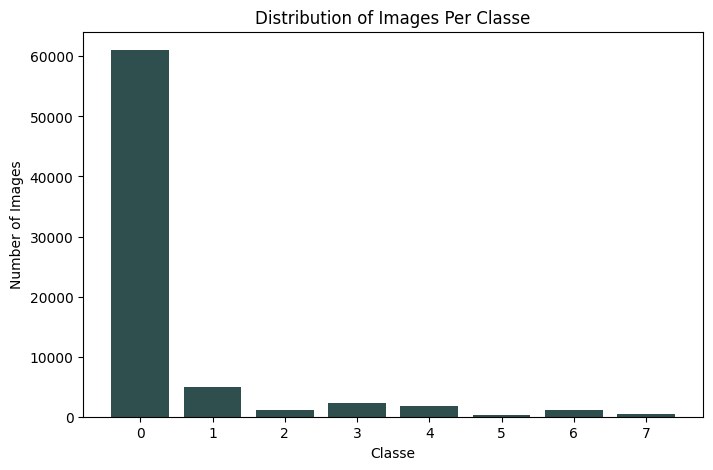

In [8]:
# count the number of images per classe

class_counts = Counter(image_labels.values())  # We will use Counter to count the number of each class where class is the id and the number is the value of the dictionanry
# if we print the variable 'class_counts' we will find:   Counter({0: 61054, 1: 4900, 3: 2331, 4: 1750, 6: 1148, 2: 1141, 7: 476, 5: 231})

print("Number of images per classe :")
for classe, count in class_counts.items():
    print(f"Classe {classe}: {count} images")



# a historgramm to visualize the distribution of each class
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='darkslategrey')
plt.xlabel("Classe")
plt.ylabel("Number of Images")
plt.title("Distribution of Images Per Classe")
plt.xticks(list(class_counts.keys()))
plt.show()


**As we can see the distribution of classes is not equal, there for we will be in need to do some data augmentation after to have the same number of images in each class to train our model!!!**

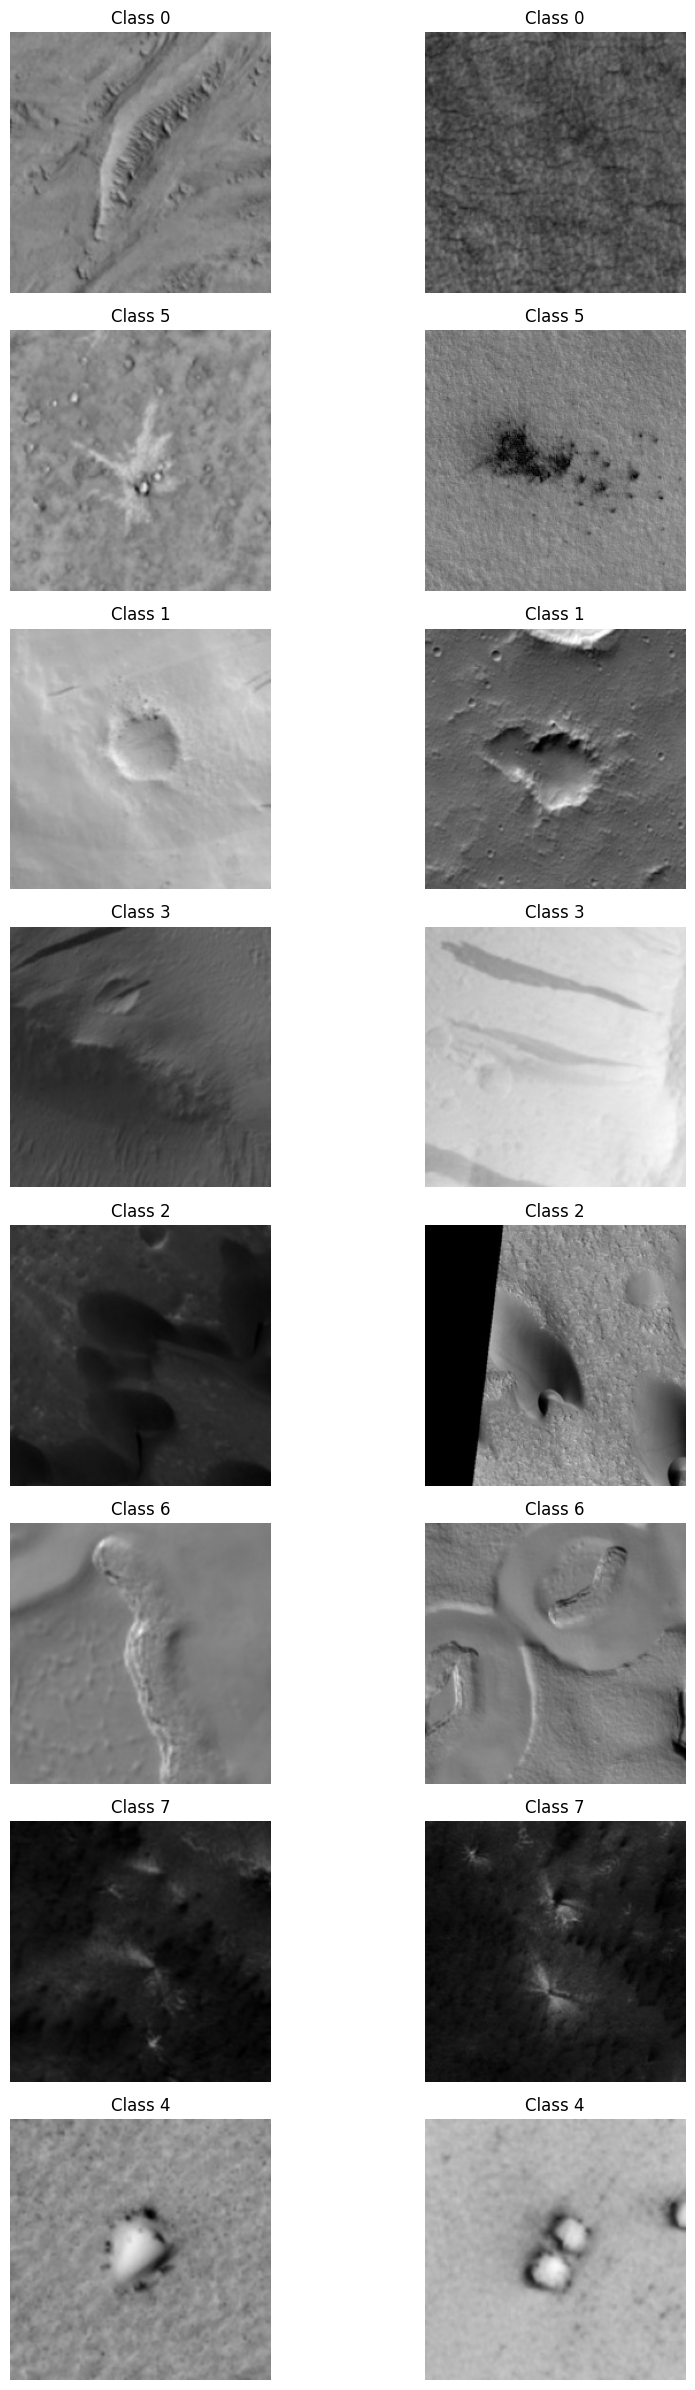

In [9]:
# # Visualize 2 images from each classe

class_images = {cls: [] for cls in class_counts.keys()}

for img_name, cls in image_labels.items():
    class_images[cls].append(img_name)

num_classes = len(class_counts.keys())
fig, axes = plt.subplots(num_classes, 2, figsize=(10, num_classes * 3))

for i, (cls, img_list) in enumerate(class_images.items()):
    if len(img_list) >= 2: 
        selected_images = random.sample(img_list, 2)
    else:
        selected_images = img_list  

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(data_path, img_name)
        img = Image.open(img_path)
        
        # Convert to RGB if necessary
        if img.mode != 'RGB':
            img = img.convert("RGB")
        
        img = np.array(img)
        if img.dtype == np.float32 or img.dtype == np.float64:
            img = (img * 255).astype(np.uint8)
        
        ax = axes[i, j]  
        ax.imshow(img, vmin=0, vmax=255)
        ax.set_title(f"Class {cls}")
        ax.axis("off")

plt.tight_layout()
plt.show()

<h1>2. Data Preprocessing</h1>

**Before we start data preprocessing, we will delete some images from the majority class 0 to help improve the time of execution.**


In [10]:



original_data_path = "/kaggle/input/datasetsnasa/Projet data science NASA/dataset"
new_data_path = "/kaggle/working/filtered_dataset"
labels_file_path = "/kaggle/input/datasetsnasa/Projet data science NASA/labels-map-proj-v3.txt"
new_labels_file_path = "/kaggle/working/filtered_labels.txt"



# Create the folder if it does'nt exist
os.makedirs(new_data_path, exist_ok=True)



# Search for image with classe 0
class_0_images = [img for img, label in image_labels.items() if label == 0]
random.shuffle(class_0_images)

# Keep only 5000 images in classe 0
images_to_keep = set(class_0_images[:5000])


filtered_labels = []

for img, label in image_labels.items():
    if label != 0 or img in images_to_keep:   # we will combine the images in the original data path with a class different from 0 with the 5000 images we just keept from above in class 0
        src_path = os.path.join(original_data_path, img)
        dest_path = os.path.join(new_data_path, img)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dest_path)  
            filtered_labels.append(f"{img} {label}")  



with open(new_labels_file_path, "w") as f:
    f.write("\n".join(filtered_labels) + "\n")

print("🎉New Dataset has been created succesufully in :", new_data_path)
print("📄 New labels file is created in :", new_labels_file_path)


🎉New Dataset has been created succesufully in : /kaggle/working/filtered_dataset
📄 New labels file is created in : /kaggle/working/filtered_labels.txt


In [11]:

# We will load the image_labels like we did before but this time we will change the name of the file, now we are using the new labels file path
image_labels = {}
with open(new_labels_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            image_labels[parts[0]] = int(parts[1])  # {'name_of_image.jpg': classe}





# Défine the new path of the dataset
new_data_path = "/kaggle/working/filtered_dataset"

# Count the number of images in each class just to make sure we have 5000 images with class 0
class_counts = {i: 0 for i in range(8)}  

for img_name in os.listdir(new_data_path):
    img_path = os.path.join(new_data_path, img_name)
    if os.path.isfile(img_path):  
        label = image_labels.get(img_name, None)
        if label is not None:
            class_counts[label] += 1

for class_id, count in class_counts.items():
    print(f"Classe {class_id}: {count} images")


Classe 0: 5000 images
Classe 1: 4900 images
Classe 2: 1141 images
Classe 3: 2331 images
Classe 4: 1750 images
Classe 5: 231 images
Classe 6: 1148 images
Classe 7: 476 images


**So now we have succefully keep only 5000 images with class 0 🎉🎉🎉**

**Now let's start data preprocessing**

In [12]:
# a. Data normalization

preprocessed_images = {}  # empty dictionnary to stock pre processed images


def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")  # Convert to RGB
    img = img.resize((227, 227))  # Redimensionning  To make sure all our images are in the same height and width
    img_array = np.array(img) / 255.0  # Normalisation [0, 1] we will take each pixel of the image and divide it with 255



# apply the normalisation to all images
for img_name in os.listdir(new_data_path):
    img_path = os.path.join(new_data_path, img_name)
    preprocessed_images[img_name] = preprocess_image(img_path)



print(f"The number of preprocessed images is : {len(preprocessed_images)}")


The number of preprocessed images is : 16977


**Normalization allows models to converge more quickly, reduces numerical instability, and also, if normalization is not performed, pixels with larger values will dominate the learning process, which will bias the model's training**

In [13]:
# b. Split the data intro train, validation and test


image_list = list(image_labels.keys())
labels_list = [image_labels[img] for img in image_list] 

# Split train (80%), val (10%), test (10%)
train_imgs, test_imgs, train_labels, test_labels = train_test_split(image_list, labels_list, test_size=0.2, stratify=labels_list, random_state=42)# 80% TRAIN 20% TEST
val_imgs, test_imgs, val_labels, test_labels = train_test_split(test_imgs, test_labels, test_size=0.5, stratify=test_labels, random_state=42) #20% TEST Is divided on 2 PART:  10% TEST AND 10% VAL

# Vérification
print(f"Train: {len(train_imgs)} images, Val: {len(val_imgs)} images, Test: {len(test_imgs)} images")


Train: 13581 images, Val: 1698 images, Test: 1698 images


So in total we have 13581+ 1698+ 1698 = 16977 images

In [14]:

# redefining paths 
augmented_images_path = new_data_path 
labels_file_path = new_labels_file_path  




# Defining our target which is 5000 images per class
target_size = 5000

# Data AUgmentation Generator
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

image_labels = {}
with open(labels_file_path, "r") as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 2:
            image_labels[parts[0]] = int(parts[1])   



# This list will save the new labels for the augmented images
new_labels = list(lines)  # Start with existing labels, 'parts' is already defined before ! 
print(len(new_labels))

# Apply data augmentation on images
for img_name in os.listdir(new_data_path):
    if img_name.endswith(".jpg") and img_name in image_labels:
        img_label = image_labels[img_name]

        # Check if the number of images in the class is < 5000
        if class_counts[img_label] < target_size:
            img_path = os.path.join(new_data_path, img_name)
            img = Image.open(img_path).convert("RGB")  
            img = img.resize((227, 227)) 
            img_array = np.array(img) /255.0  #  img_array = np.array(img) / 255.0 !!!!!!!!!!!!!!!!!!!!!!!!!!!!


            img_array = img_array.reshape((1,) + img_array.shape)  #ImageDataGenerator in Keras need an array of imageswith the form  (batch_size, height, width, channels) a normal iùmage is like (height, width, channels)
                                  
            # That's why we need to add a shape to have (1,227,227,3)


            
            # Generate augmented images
            while class_counts[img_label] < target_size:
                augmented_img = next(datagen.flow(img_array, batch_size=1))[0]
                new_img_name = f"{img_name}_aug_{class_counts[img_label]}.jpg"  # The new name of the augmented images will be like this "image1_aug_10.jpg"

                # Save the augmented image
                augmented_img_pil = Image.fromarray((augmented_img * 255).astype(np.uint8))
                augmented_img_pil.save(os.path.join(augmented_images_path, new_img_name))

                # Add the new label to the file of labels
                new_labels.append(f"{new_img_name} {img_label}\n")

                # update the counter until reaching 5000 images per class
                class_counts[img_label] += 1

# write new labels in the file
with open(labels_file_path, "w") as f:
    f.writelines(new_labels)

print("Data Augmentation Done!")
print("Filtered labels file updated successfully!")


16977
Data Augmentation Done!
Filtered labels file updated successfully!


In [15]:
# let's check if we have exactly 5000 images in each class after data augmentation
# Defining the new labels_file_path including labels of the augmented images
labels_file_path = "/kaggle/working/filtered_labels.txt"
image_labels = {}
with open(labels_file_path, "r") as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 2:
            image_labels[parts[0]] = int(parts[1])   
class_counts = {i: 0 for i in range(8)} 
for img, label in image_labels.items():
    class_counts[label] += 1




print("Number of images after data augmentation :")
for cls, count in class_counts.items():
    print(f"Classe {cls} : {count} images")


if all(count == 5000 for count in class_counts.values()):
    print("All classes have exactly 5000 images !")
else:
    print("Some classes doesn't have exactly 5000 images!!!!")


Number of images after data augmentation :
Classe 0 : 5000 images
Classe 1 : 5000 images
Classe 2 : 5000 images
Classe 3 : 5000 images
Classe 4 : 5000 images
Classe 5 : 5000 images
Classe 6 : 5000 images
Classe 7 : 5000 images
All classes have exactly 5000 images !


<h1>3. Machine Learning Models</h1>

**We will use ResNet Model**

In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

import cv2


<pre>train_imgs, test_imgs, train_labels, test_labels = train_test_split(image_list, labels_list, test_size=0.2, stratify=labels_list, random_state=42)
val_imgs, test_imgs, val_labels, test_labels</pre>

In [17]:
import tensorflow as tf


# Load ResNet without the last layer because we need to modify it and personalized it based on our dataset
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(227, 227, 3))

# Add some classifcation layers
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)  # added a batch normalisation
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)


x = Dense(8, activation='softmax')(x)  # We have 8 classes to predict [0, 1, 2, 3, 4, 5, 6, 7]

# Construct the final model
model = Model(inputs=base_model.input, outputs=x)



# Freeze ResNet50 layers for initial training
for layer in base_model.layers[-10:]:  
    layer.trainable = False  # True




# I added this line 
adam = tf.keras.optimizers.Adam(learning_rate=1e-5)






I0000 00:00:1739708878.229497      10 service.cc:148] XLA service 0x5c9ee9510e00 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739708878.229550      10 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1739708878.229555      10 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1739708878.229558      10 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1739708878.229560      10 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1739708878.229563      10 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1739708878.229566      10 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1739708878.229568      10 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1739708878.229571      10 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [18]:
# Compile the model
model.compile(optimizer= adam, loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=False)  # We used categotical_crossentropy because we have multiclasse classification

# Reducing learning rate in case val_accuraccy doesn't imrove after 5 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=5, min_lr=1e-4) # To reduce overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)  # To reduce overfitting


# Normalising Labels to categorical format
Y_train = to_categorical(train_labels, num_classes=8)
Y_val = to_categorical(val_labels, num_classes=8)
Y_test = to_categorical(test_labels, num_classes=8)


# Load and preprocess images
def load_images(image_paths):
    images = []
    for img_path in image_paths:
        img = cv2.imread(os.path.join(new_data_path, img_path))  
        img = cv2.resize(img, (227, 227))
        img = img / 255.0  # Normalize pixel values
        images.append(img)
    return np.array(images)



In [19]:

# Load train, val and test images
X_train = load_images(train_imgs)
X_val = load_images(val_imgs)
X_test = load_images(test_imgs)

print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)


(13581, 227, 227, 3) (13581, 8) (1698, 227, 227, 3) (1698, 8) (1698, 227, 227, 3) (1698, 8)


In [20]:
# Data augmentation for training

"""from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, Y_train, batch_size=32)""" # 256


'from tensorflow.keras.preprocessing.image import ImageDataGenerator\n\ntrain_datagen = ImageDataGenerator(\n    rotation_range=20,\n    width_shift_range=0.2,\n    height_shift_range=0.2,\n    horizontal_flip=True\n)\n\ntrain_generator = train_datagen.flow(X_train, Y_train, batch_size=32)'

In [21]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


In [22]:
# Train the model
cache = model.fit(X_train, Y_train, 
                  batch_size=32, 
                  epochs=10,
                  validation_data=(X_val, Y_val),
                  callbacks=[early_stopping, reduce_lr],
                 verbose=1)

Epoch 1/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1355s 3s/step - accuracy: 0.4628 - loss: 9.8662 - val_accuracy: 0.1649 - val_loss: 13.8691 - learning_rate: 1.0000e-05
Epoch 2/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1284s 3s/step - accuracy: 0.8484 - loss: 8.4379 - val_accuracy: 0.6019 - val_loss: 9.0246 - learning_rate: 1.0000e-05
Epoch 3/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1277s 3s/step - accuracy: 0.9161 - loss: 8.0084 - val_accuracy: 0.8663 - val_loss: 7.9493 - learning_rate: 1.0000e-05
Epoch 4/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1295s 3s/step - accuracy: 0.9405 - loss: 7.6500 - val_accuracy: 0.9276 - val_loss: 7.4683 - learning_rate: 1.0000e-05
Epoch 5/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1274s 3s/step - accuracy: 0.9537 - loss: 7.2991 - val_accuracy: 0.9470 - val_loss: 7.0728 - learning_rate: 1.0000e-05
Epoch 6/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1309s 3s/step - accuracy: 0.9715 - loss: 6.9188 - val_accuracy: 0.9529 - val_loss: 6.6960 - learning_rate: 1.0000e-05
Epoch 7/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 1288s 3s/st

In [23]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_acc:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step - accuracy: 0.9572 - loss: 5.0390
Test Accuracy: 0.9547


In [33]:
model.save('/kaggle/working/final_model.h5')

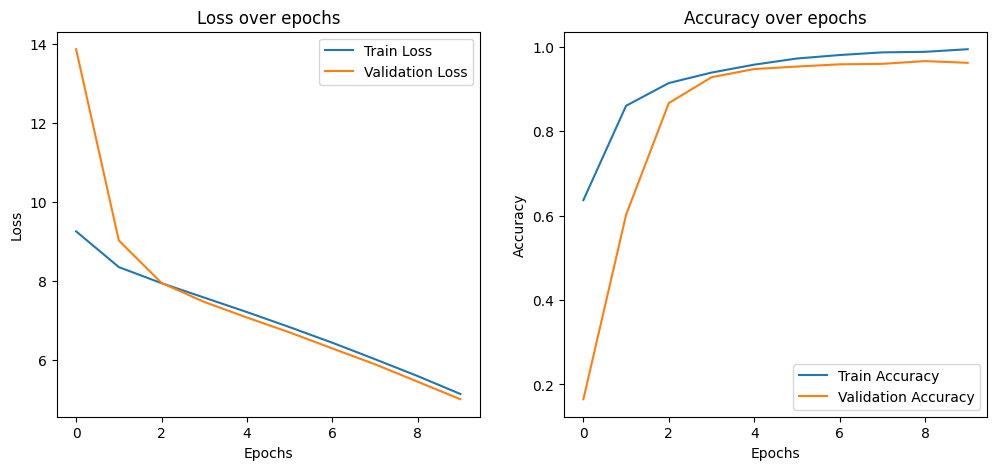

In [25]:


history = cache.history


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')


plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.show()


54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 546ms/step


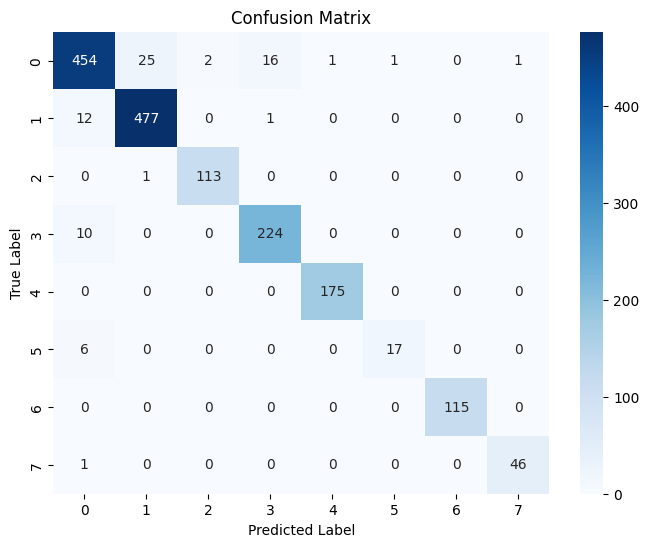

In [26]:
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  
y_true = np.argmax(Y_test, axis=1) 


conf_mat = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


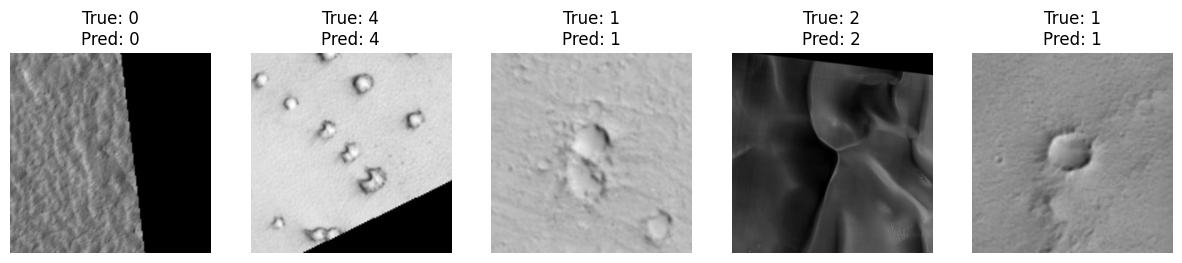

In [27]:
import random

num_images = 5
indices = random.sample(range(len(X_test)), num_images)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = np.argmax(Y_test[idx])
    pred_label = np.argmax(model.predict(img.reshape(1, *img.shape)))

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img, cmap='gray') 
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()


In [28]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 24.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.8/315.8 kB 27.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283884 sha256=09673e06c01461837fdfa682448add924a6b1da053e02668561ac5f277204e88
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


  1%|          | 10/1000 [00:00<00:35, 28.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


  2%|▏         | 20/1000 [00:00<00:33, 29.56it/s]

...

 98%|█████████▊| 980/1000 [00:32<00:00, 32.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


 99%|█████████▉| 990/1000 [00:33<00:00, 32.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


100%|██████████| 1000/1000 [00:33<00:00, 29.99it/s]


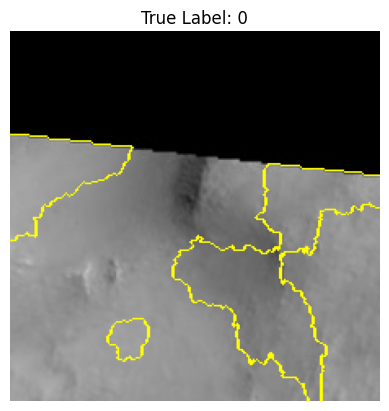

In [32]:
import lime
import lime.lime_image

explainer = lime.lime_image.LimeImageExplainer()

# Selct a random image
idx = np.random.randint(len(X_test))
image = X_test[idx]
true_label = np.argmax(Y_test[idx])

explanation = explainer.explain_instance(image, 
                                         model.predict, 
                                         top_labels=1, 
                                         hide_color=0, 
                                         num_samples=1000)

from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()


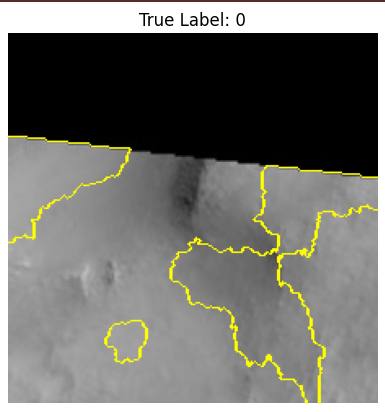
</br>
<h3>The highlighted area indicates which parts of the image had the most influence on the model's decision.</h3>

<h1> <center>THE END </h1>